<a href="https://colab.research.google.com/github/andersonmoraix/anotacoeseconometria/blob/main/aula1_econometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Econometria Aplicada [Módulo em Python]
### Regressão linear simples

In [ ]:
#!pip install numpy
#!pip install matplotlib
!pip install wooldridge
#!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import wooldridge as woo
plt.rcParams['figure.dpi'] = 150

## Introdução

Regressão linear  é um método para encontrar relações entre variáveis. Por exemplo, você pode observar vários funcionários de alguma empresa e tentar entender como seus salários dependem de características, educação, experiência, local de trabalho, cargo, entre outros. Neste caso, os dados relacionados a cada funcionário representam uma observação - uma linha na planilha. A nossa hipótese é que essas características são independentes e o salário é dependente delas.

Para encontrar essa relação você precisa encontrar uma função que forneça um bom ajuste entre a suas características e a variável dependente. A regressão linear ajusta os dados, como o próprio nome diz, com uma função linear, pelo método de mínimos quadrados ordinários (OLS).

Suponha que estejamos interessados especificamente na relação da escolaridade com o salário. Assim, esperamos que, quanto maior os anos de estudo, maior o salário de uma pessoa. Assim, digamos que um ano a mais aumente o salário em média em 100 reais. Além disso, espera-se que, mesmo que uma pessoa não tenha estudado, ela receba em média 500 reais. Essa relação pode ser descrita da seguinte forma:

\begin{equation}
y=\beta_{0}+\beta_{1} x+u
\end{equation}

Em que $y$ é o salário, $x$ os anos de estudo, $\beta_{0}$ o salário médio sem nenhum estudo, $\beta_{1}$ o aumento do salário causado por um ano adicional de estudo e $u$ um termo de erro, pois essa relação não é exata e depende de outros fatores. O objetivo da regressão linear é estimar os parâmetros $\beta$, principalmente o chamado coeficiente angular, $\beta{1}$.

Assim, podemos estimar esses parâmetros da seguinte forma:

\begin{equation}
\begin{aligned}
&\hat{\beta}_{0}=\bar{y}-\hat{\beta}_{1} \bar{x} \\
&\hat{\beta}_{1}=\frac{\operatorname{Cov}(x, y)}{\operatorname{Var}(x)}
\end{aligned}
\end{equation}

Em que $\bar{y}$ e $\bar{x}$ são a média de $y$ e $x$.  O que gera uma linha de regressão:

\begin{equation}
\hat{y}=\hat{\beta}_{0}+\hat{\beta}_{1} x \text { . }
\end{equation}

Basicamente, precisamos calcular quatro estatísticas: $\bar{y}$, $\bar{x}$, $\operatorname{Cov}(x, y)$ e $\operatorname{Var}(x)$.

Para mostrar isso, vamos utilizar uma base de dados com várias características de pessoas, incluindo educação e salário. Estamos interessados, portanto, apenas nas duas primeiras colunas.

In [ ]:
wage1 = woo.dataWoo('wage1')
wage1.head()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
1,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
2,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4


Assim:

In [ ]:
x = wage1['educ']
y = wage1['wage']

# As quatro estatísticas:
cov_xy = np.cov(x, y)[1, 0]
var_x = np.var(x, ddof=1)
x_bar = np.mean(x)
y_bar = np.mean(y)

# Cálculo do OLS:
b1 = cov_xy / var_x
b0 = y_bar - b1 * x_bar
print(f'b1: {b1}\n')
print(f'b0: {b0}\n')

b1: 0.5413592546651745

b0: -0.904851611957211



Veja que o nosso parâmetro de interesse deu o valor na direção esperada. Isto é, maio a escolaridade, maior o salário. Mais especificamente, um ano a mais aumenta em 54 centavos de dólar por hora o salário.

Entretanto, existe um jeito mais simples e eficiente de estimar a regressão que é utilizando o pacote statsmodel.

In [ ]:
wage1 = woo.dataWoo('wage1')

reg = smf.ols(formula='wage ~ educ', data=wage1)
results1 = reg.fit()
results1.params

Intercept   -0.904852
educ         0.541359
dtype: float64

O primeiro argumento nós colocamos a formula da regressão. Ou seja, a variável do lado esquerdo ao "~" é explicada pela variável do lado direito. O cálculo de fato do estimador OLS é realizado com a função "fit()". Assim, extraímos os parâmetros, que estão armazenados em "params".

Veja que com a utilização do pacote matplotlib, podemos mostrar o gráfico de dispersão entre as duas variáveis e a reta de regressão.

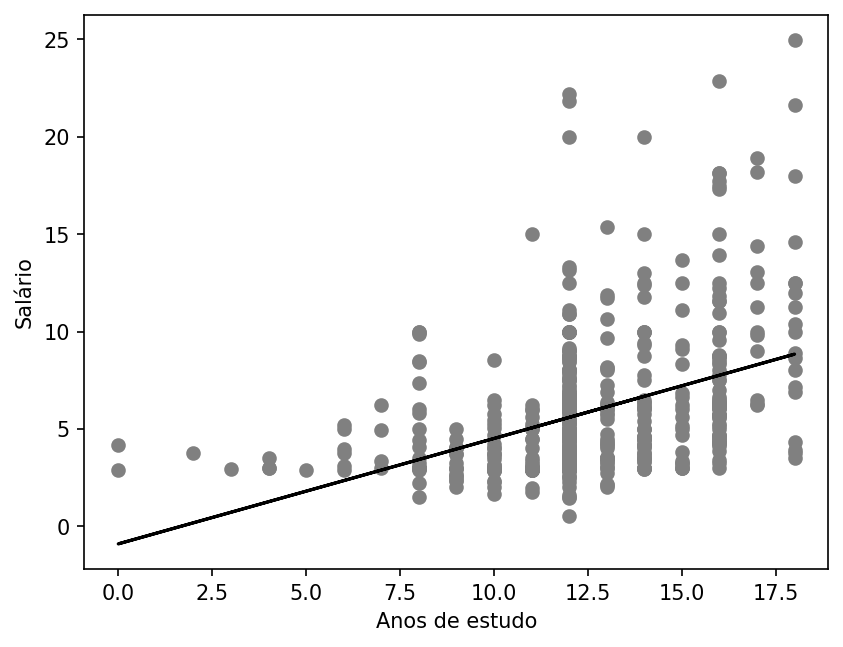

In [ ]:
# Gráfico de dispersão:
plt.plot('educ', 'wage', data=wage1, color='grey', marker='o', linestyle='')
plt.plot(wage1['educ'], results1.fittedvalues, color='black', linestyle='-')
plt.ylabel('Salário')
plt.xlabel('Anos de estudo');

## Coeficientes, valores ajustados e resíduos

Além dos parâmetros, o objeto retornado pela função "fit" contém várias informações importantes que podemos analisar. Para acessa-las, precisamos utilizar o mesmo padrão que para acessar os coeficientes, ou seja, "results.nomedoobjeto". Para abrir uma lista dos objetos dentro do resultado digite "results." e aperte a tecla tab.

O objeto "params" tem nomes associados aos coeficientes. o $\beta_{0}$ é "intercept", ou intercepto em português, e o $\beta_{1}$ é "slope", que se traduz para angular. Assim, podemos acessar cada um deles individualmente da seguinte maneira:

In [ ]:
print(results1.params[0]) #Intercepto
print(results1.params[1]) # Beta 1
print(results1.params["educ"]) # Beta 1

-0.9048516119572085
0.541359254665175
0.541359254665175


Como temos os parâmetros podemos estimar os valores previstos $\hat{y}$ e os resíduos $\hat{u}$ para cada observação.

\begin{equation}
\begin{aligned}
&\hat{y}_{i}=\hat{\beta}_{0}+\hat{\beta}_{1} \cdot x_{i} \\
&\hat{u}_{i}=y_{i}-\hat{y}_{i}
\end{aligned}
\end{equation}

Para isso:

In [ ]:
y_hat = results1.fittedvalues
u_hat = results1.resid

print(y_hat)
print(u_hat)

0      5.050100
1      5.591459
2      5.050100
3      3.426022
4      5.591459
         ...   
521    7.756896
522    4.508741
523    7.215537
524    7.756896
525    6.674178
Length: 526, dtype: float64
0     -1.950100
1     -2.351459
2     -2.050100
3      2.573978
4     -0.291459
         ...   
521    7.243104
522   -2.238741
523   -2.545537
524    3.803104
525   -3.174178
Length: 526, dtype: float64


## Qualidade de ajuste

A qualidade do ajuste de um modelo estatístico descreve o quão bem ele se ajusta a um conjunto de observações. Em um modelo bem ajustado, a diferença entre os valores observados e os valores ajustados pelo modelo são pequenas. Como podemos observar pelo gráfico que plotamos acima, o ajuste do nosso modelo não ficou muito adequado, pois a relação entre as duas variáveis não é linear e tem muito ruído.

Utilizando um exemplo da influência do gasto na campanho nos resultados eleitorais, podemos mostrar um modelo melhor ajustado:

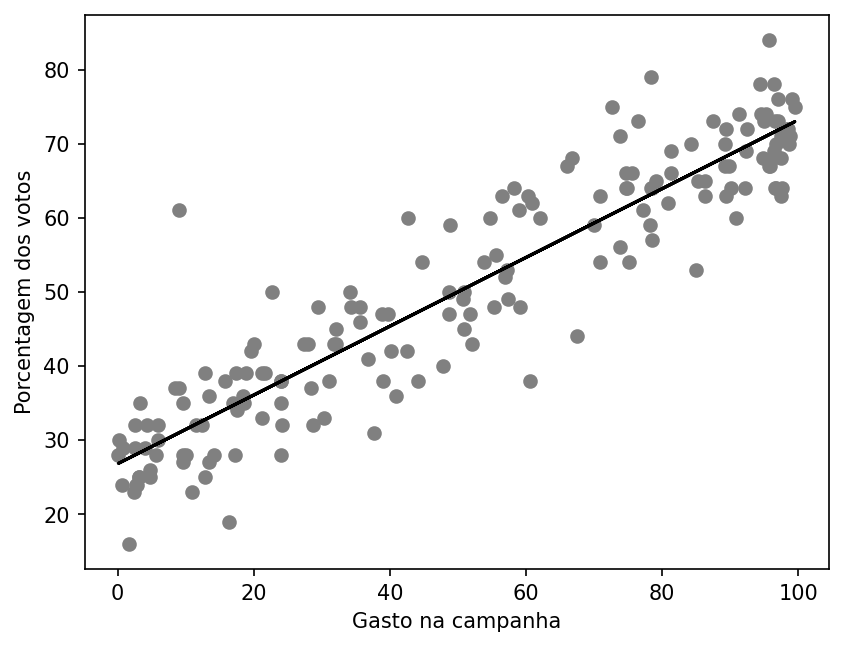

In [ ]:
vote1 = woo.dataWoo('vote1')

# Estimando o OLS:
reg = smf.ols(formula='voteA ~ shareA', data=vote1)
results2 = reg.fit()

# dispersão:
plt.plot('shareA', 'voteA', data=vote1, color='grey', marker='o', linestyle='')
plt.plot(vote1['shareA'], results2.fittedvalues, color='black', linestyle='-')
plt.ylabel('Porcentagem dos votos')
plt.xlabel('Gasto na campanha');

Para representar mais tecnicamente temos três componentes principais. A soma dos quadrados explicados (SSE), soma dos quadrados dos resíduos (SSR) e soma dos quadrados total (SST):

\begin{equation}
\begin{aligned}
&\mathrm{SST}=\sum_{i=1}^{n}\left(y_{i}-\bar{y}\right)^{2}=(n-1) \cdot \operatorname{Var}(y) \\
&\mathrm{SSE}=\sum_{i=1}^{n}\left(\hat{y}_{i}-\bar{y}\right)^{2}=(n-1) \cdot \operatorname{Var}(\hat{y}) \\
&\mathrm{SSR}=\sum_{i=1}^{n}\left(\hat{u}_{i}-0\right)^{2}=(n-1) \cdot \operatorname{Var}(\hat{u})
\end{aligned}
\end{equation}

A variação explicada pelo modelo de regressão é igual ao SSE, que por sua vez é igual a diferença entre SST e o SSR. Para padronizar, nós utilizamos o chamado coeficiente de determinação, o $R^{2}$.

\begin{equation}
R^{2}=\frac{\operatorname{Var}(\hat{y})}{\operatorname{Var}(y)}=1-\frac{\operatorname{Var}(\hat{u})}{\operatorname{Var}(y)}
\end{equation}

Esse coeficiente de determinação vai de 0 a 1 e diz o quanto da variação da varíavel dependente pode ser explicado pelo modelo que estimamos.

Para acessar o $R^{2}$ podemos simplesmente:

In [ ]:
print(results1.rsquared)
print(results2.rsquared)

0.1647575109920515
0.8561408655827665


Perceba que o ajuste da segundo exemplo é bem melhor do que o do primeiro.

## Modificações

No gráfico de dispersão do exemplo de escolaridade e salários é possível perceber que a relação entre as variáveis não é exatamente linear. Neste caso, é possível fazer pequenas alterações no modelo para estimar uma relação mais realista. Mais especificamente, é muito comum estimar as variáveis com a transformação logarítimica. Isto pode ser feito de maneira simples:


In [ ]:
reg = smf.ols(formula='np.log(wage) ~ educ', data=wage1)
#Ou
wage1["wage_log"] = np.log(wage1["wage"])
reg = smf.ols(formula='wage_log ~ educ', data=wage1)

results3 = reg.fit()
print(results3.params)

Intercept    0.583773
educ         0.082744
dtype: float64


Entretanto, isso causa alterações na interpretação. Agora, o modelo mostra que um aumento de um ano de escolaridade aumenta o salário em 8.3%.

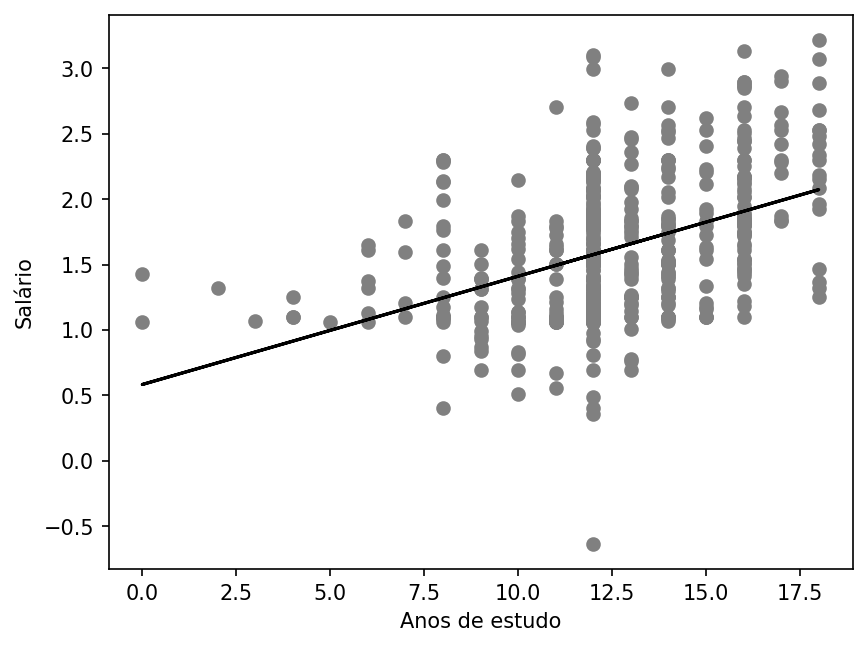

In [ ]:
# Gráfico de dispersão:
plt.plot('educ', 'wage_log', data=wage1, color='grey', marker='o', linestyle='')
plt.plot(wage1['educ'], results3.fittedvalues, color='black', linestyle='-')
plt.ylabel('Salário')
plt.xlabel('Anos de estudo');

In [ ]:
print(results3.rsquared)

0.18580647728823496


Veja que o ajuste melhorou um pouco.

Também é possível estimar a regressão sem o parâmetro do intercepto ou coeficiente angular. Para isso:

In [ ]:
reg = smf.ols(formula='wage ~ 0 + educ', data=wage1) # Sem o intercepto
reg = smf.ols(formula='wage_log ~ 1', data=wage1) # Sem o coeficiente angular

Entretanto, normalmente não é recomendado nenhuma das duas especificações acima.

## Hipóteses

Existem cinco hipóteses principais quando estamos estimando uma regressão OLS:
    
1. A relação populacional entre as variáveis é linear
2. A amostra das variáveis é aleatória
3. Há variação nos valores amostrais
4. O erro é independente de $x$: $\mathrm{E}(u \mid x)=0$
5. Homocedasticidade, ou seja, a variância é constante em relação a $x$: $\operatorname{Var}(u \mid x)=\sigma^{2}$

## Erro padrão

Podemos calcular o erro padrão da regressão $\sigma$ pela raíz quadrada seguinte estimador:

\begin{equation}
\hat{\sigma}^{2}=\frac{1}{n-2} \cdot \sum_{i=1}^{n} \hat{u}_{i}^{2}=\frac{n-1}{n-2} \cdot \operatorname{Var}\left(\hat{u}_{i}\right),
\end{equation}

Em que $\operatorname{Var}\left(\hat{u}_{i}\right)=\frac{1}{n-1} \cdot \sum_{i=1}^{n} \hat{u}_{i}^{2}$. Temos que utilizar ajustes de graus de liberdade na construção dos resíduos pois estamos estimando dois parâmetros. Já os erros padrão dos parâmetros podem ser estimados da seguinte forma:


\begin{equation}
\begin{aligned}
&\operatorname{se}\left(\hat{\beta}_{0}\right)=\sqrt{\frac{\hat{\sigma}^{2} \overline{x^{2}}}{\sum_{i=1}^{n}(x-\bar{x})^{2}}}=\frac{1}{\sqrt{n-1}} \cdot \frac{\hat{\sigma}}{\operatorname{sd}(x)} \cdot \sqrt{\overline{x^{2}}} \\
&\operatorname{se}\left(\hat{\beta}_{1}\right)=\sqrt{\frac{\hat{\partial}^{2}}{\sum_{i=1}^{n}(x-\bar{x})^{2}}}=\frac{1}{\sqrt{n-1}} \cdot \frac{\hat{\sigma}}{\operatorname{sd}(x)}
\end{aligned}
\end{equation}




Usualmente estaremos interessados em produzir uma tabela com os resultados da regressão. Isso pode ser facilmente feito com a função "summary()". Nele temos várias informações sobre o modelo que trataremos ao longo do curso, assim como algumas que comentamos nesta aula, como os coeficientes e os erros padrão do parâmetro no centro e o $R^{2}$ à direita e acima.

In [ ]:
print(f'results1.summary(): \n{results1.summary()}\n')

results1.summary(): 
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Wed, 19 Jul 2023   Prob (F-statistic):           2.78e-22
Time:                        13:31:36   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9049      0.68